В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
import os
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_curve, auc
import operator
from sklearn.preprocessing import PolynomialFeatures

Area under ROC score on train dataset: 0.8821%


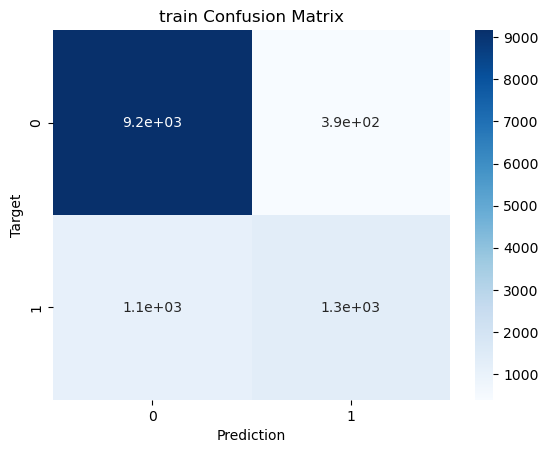

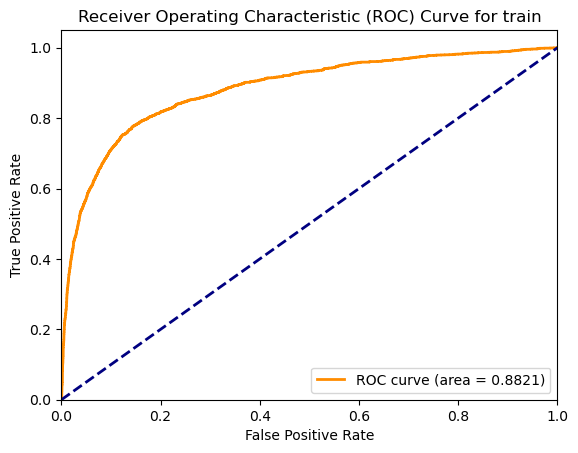

Area under ROC score on Validation dataset: 0.8792%


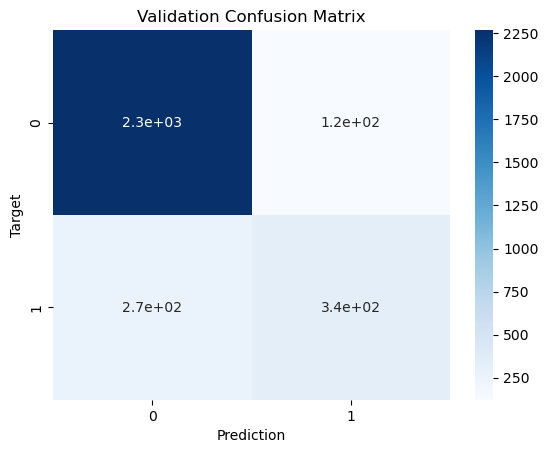

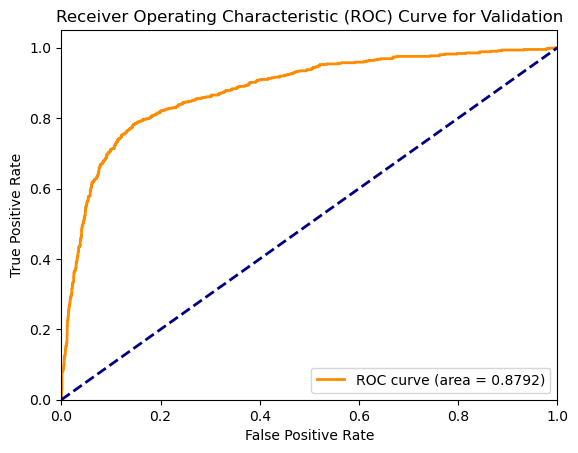

In [25]:
raw_df = pd.read_csv('train.csv', index_col=0)

train_df, val_df = train_test_split(raw_df, test_size=0.20, random_state=42, stratify=raw_df["Exited"])

# Створюємо трен. і вал. набори
input_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',  LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    fpr, tpr, thresholds = roc_curve(targets, model_pipeline.predict_proba(inputs)[:, 1], pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.4f}%")
    confusion_matrix_ = confusion_matrix(targets, preds)
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
    plt.legend(loc="lower right")
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
#joblib.dump(...)


In [27]:
print(model_pipeline.named_steps['classifier'].coef_)
print(len(numeric_cols), numeric_cols)
X_poly = numeric_transformer_poly2.fit_transform(train_inputs[numeric_cols])
print(X_poly.shape)

[[-0.87331165  8.44015801 -1.09142626 -3.94082155 -1.25027076 -0.9712544
   0.59302593 -1.0646996  -0.2916351  -1.15129296]]
5 ['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember']
(12000, 20)


**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on train dataset: 0.9105%


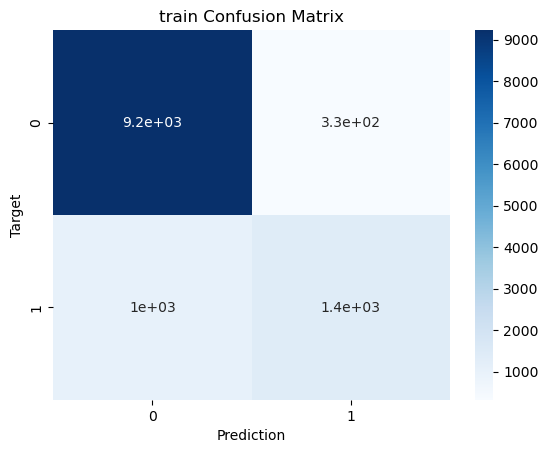

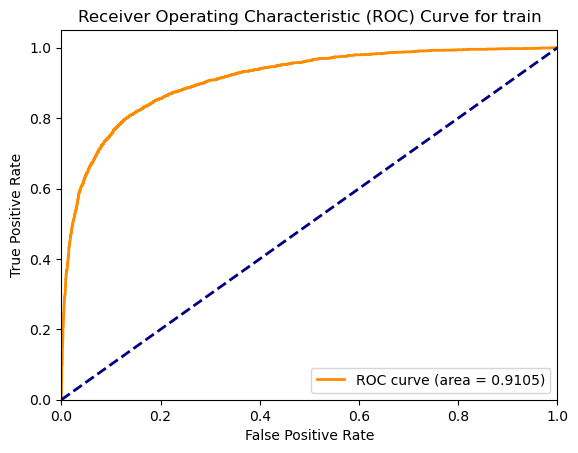

Area under ROC score on Validation dataset: 0.9095%


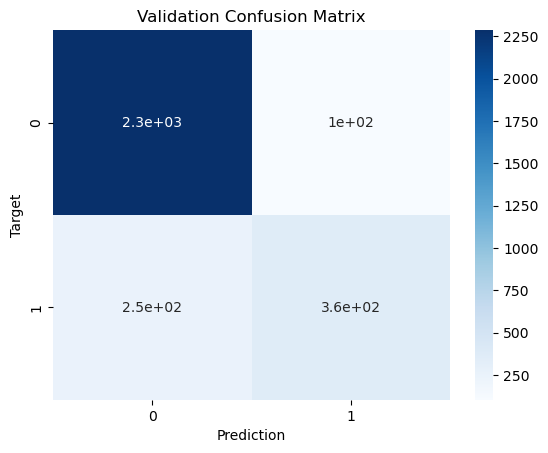

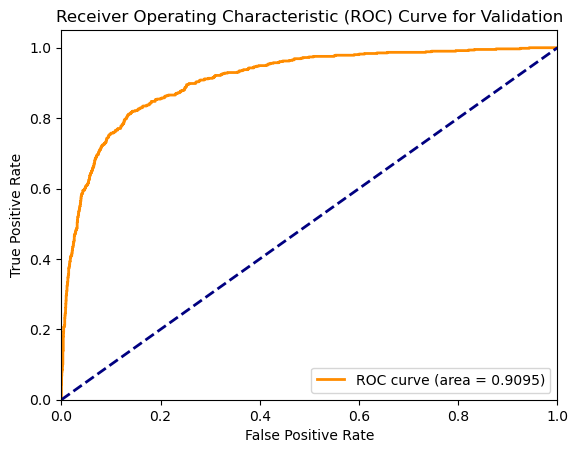

In [29]:
numeric_transformer_poly2 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', MinMaxScaler())
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor_poly2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly2, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_poly2 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly2),
    ('classifier',  LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline_poly2.fit(train_inputs, train_targets)

train_preds = predict_and_plot(model_pipeline_poly2, train_inputs, train_targets, 'train')
val_preds = predict_and_plot(model_pipeline_poly2, val_inputs, val_targets, 'Validation')

In [51]:
model_pipeline_poly2.named_steps['classifier'].coef_

array([[-0.87270577,  8.4514612 , -0.07507594, -1.09522711, -3.93463705,
        -0.18752677, -1.25346135,  0.1893298 , -0.96015514,  0.60793952,
        -1.05332183, -0.27211848, -1.13341897]])

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on train dataset: 0.9290%


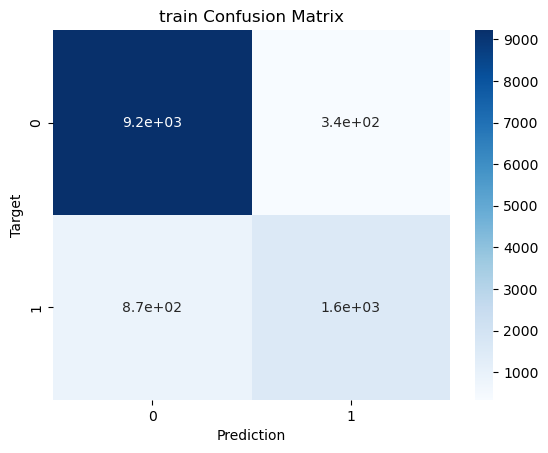

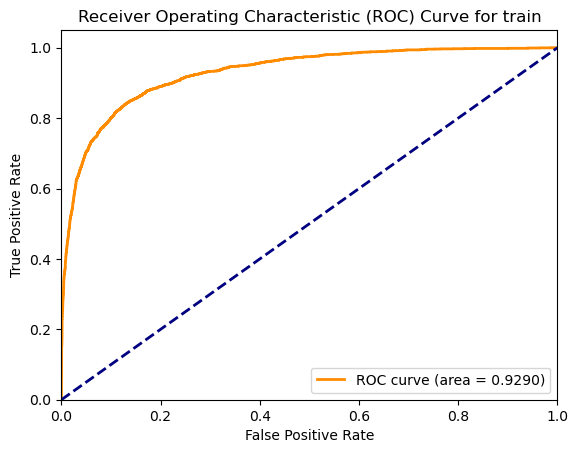

Area under ROC score on Validation dataset: 0.9277%


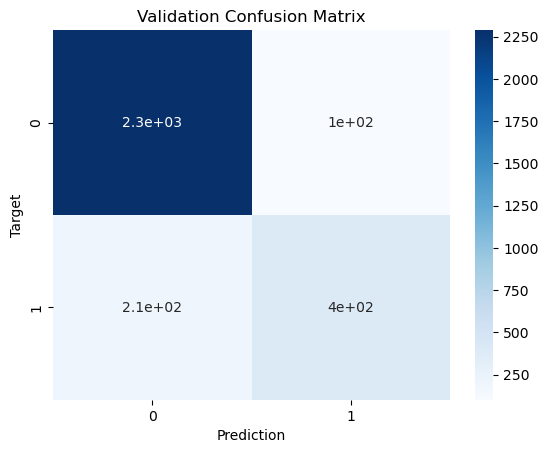

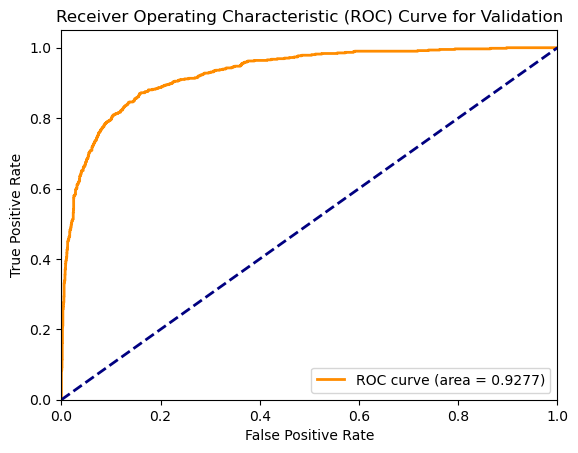

In [31]:
numeric_transformer_poly4 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', MinMaxScaler())
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor_poly4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),
    ('classifier',  LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline_poly4.fit(train_inputs, train_targets)

train_preds = predict_and_plot(model_pipeline_poly4, train_inputs, train_targets, 'train')
val_preds = predict_and_plot(model_pipeline_poly4, val_inputs, val_targets, 'Validation')

In [11]:
test_raw_df = pd.read_csv('test.csv')
test_raw_df['Exited'] = model_pipeline_poly4.predict_proba(test_raw_df)[:, 1]
test_raw_df['Exited'].value_counts()

Exited
0.085121    1
0.467798    1
0.170229    1
0.288152    1
0.012448    1
           ..
0.021785    1
0.003143    1
0.149346    1
0.061800    1
0.083424    1
Name: count, Length: 10000, dtype: int64

In [13]:
submission = pd.read_csv('sample_submission.csv')
submission['Exited'] = test_raw_df['id'].map(test_raw_df.set_index('id')['Exited'])
submission.to_csv('submission_log_reg1.csv', index=False)

In [87]:
print(train_inputs.columns)

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary'],
      dtype='object')


**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

reg_df = pd.read_csv('regression_data.csv', index_col=0)

reg_train_df, reg_test_df = train_test_split(reg_df, test_size=0.20, random_state=42)

# Створюємо трен. і вал. набори
input_cols = list(reg_train_df.columns)[0:-1]
target_col = 'target'
reg_train_inputs, reg_train_targets = reg_train_df[input_cols].copy(), reg_train_df[target_col].copy()
reg_test_inputs, reg_test_targets = reg_test_df[input_cols].copy(), reg_test_df[target_col].copy()

numeric_transformer_poly5 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', MinMaxScaler())
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor_poly5 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly5, input_cols),
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_poly5 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly5),
    ('classifier', LinearRegression())
])

# Тренуємо пайплайн
model_pipeline_poly5.fit(reg_train_inputs, reg_train_targets)

y_pred = model_pipeline_poly5.predict(reg_train_inputs)
y_test_pred = model_pipeline_poly5.predict(reg_test_inputs)

print("RMSE:", np.sqrt(mean_squared_error(reg_train_targets, y_pred)))
print("RMSE test:", np.sqrt(mean_squared_error(reg_test_targets, y_test_pred)))

# train_preds = predict_and_plot(model_pipeline_poly5, reg_train_inputs, reg_train_targets, 'train')
# val_preds = predict_and_plot(model_pipeline_poly5, reg_val_inputs, reg_val_targets, 'Validation')

RMSE: 2.1724542593365108e-13
RMSE test: 89.7945690175543


Для трейна RMSE - 0.000000000000217, а для тесту 89.795. Модель дуже сильно перенавчається

In [47]:
reg_df = pd.read_csv('regression_data.csv', index_col=0)
reg_df

,feature_2,feature_3,feature_4,feature_5,target
feature_1,,,,,
-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013
...,...,...,...,...,...
1.402794,0.586857,-1.401851,0.791032,-0.909387,39.626185
-0.288659,-0.827231,0.322719,-1.002529,-0.018513,-50.585687
-1.407464,-0.213447,-0.718444,0.232050,-1.448084,13.719861


**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [60]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
models = [
    Ridge(),
    Lasso(),
    ElasticNet()
]

In [72]:
poly = PolynomialFeatures(degree=20, include_bias=False)
for model in models:
    numeric_transformer_poly20 = Pipeline(steps=[
        ('poly', PolynomialFeatures(degree=20, include_bias=False)),
        ('scaler', MinMaxScaler())
    ])
    
    # Комбінуємо трансформери для різних типів колонок в один препроцесор
    preprocessor_poly20 = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer_poly20, input_cols),
        ])
    
    # Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
    model_pipeline_poly20 = Pipeline(steps=[
        ('preprocessor', preprocessor_poly20),
        ('classifier', model)
    ])
    
    # Тренуємо пайплайн
    model_pipeline_poly20.fit(reg_train_inputs, reg_train_targets)
    
    y_pred = model_pipeline_poly20.predict(reg_train_inputs)
    y_test_pred = model_pipeline_poly20.predict(reg_test_inputs)
    
    print(f'{str(model)}: {np.sqrt(mean_squared_error(reg_train_targets, y_pred))}\n')
    print(f'{str(model)}: {np.sqrt(mean_squared_error(reg_test_targets, y_test_pred))}\n')

    poly.fit(reg_train_inputs[input_cols])
    poly_feature_names = poly.get_feature_names_out(input_cols)
    model_trained = model_pipeline_poly20.named_steps['classifier']
    coefs_df = pd.DataFrame({
        'feature_name': poly_feature_names,
        'value': model_trained.coef_.flatten().round(5)
    })
    filtered_coefs = coefs_df[np.abs(coefs_df['value']) >= 5]
    display(filtered_coefs.set_index('feature_name').sort_values(by='value', ascending=False).style.background_gradient())

Ridge(): 8.934199001156314

Ridge(): 71.03441486967033



,value
feature_name,
feature_4,121.532220
feature_4^3,29.725630
feature_4 feature_5^2,20.135930
feature_2^2 feature_4,17.580310
feature_3^2 feature_4,14.664810
feature_2^2 feature_4^3,11.479950
feature_4^5,10.643420
feature_2^2 feature_3^2 feature_4,7.372740
feature_4 feature_5^4,7.303910


Lasso(): 5.098171369261126

Lasso(): 5.671930522041579



,value
feature_name,
feature_4,194.929250


ElasticNet(): 35.69968344204754

ElasticNet(): 83.23323733553705



,value
feature_name,
feature_4,12.941350
feature_4^3,5.060090


Lasso зменьшив всі коефіцієнти крім одного меньше ніж 0.5 по модулю (поріг для коєфіціентів я збільшила пізніше, щоб трошки зменшити аутпут). Тому він краще всіх впорався з перенавчанням і в нього найменьша середньоквадратична помилка